<div style="background-color:#ED1C24; color:white; padding:20px 30px; border-radius:10px;">
<h1 style="color:white; margin:0;">Session 7.1: Probability Distributions</h1>
<p style="color:white; margin:5px 0 0 0;">Practical Lab — Normal, Binomial, Poisson, Exponential & SciPy Fitting</p>
</div>

## Learning Objectives

1. Describe the Normal distribution and apply the 68-95-99.7 rule
2. Compute z-scores to assess how unusual a value is
3. Use the Binomial distribution for counting successes in fixed trials
4. Use the Poisson distribution for events per time interval
5. Use Exponential and Uniform distributions
6. Fit distributions to data using SciPy
7. Apply the decision flowchart to select the right distribution

## Setup

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)
print(f"NumPy: {np.__version__}")
print("Setup complete!")

NumPy: 2.4.6
Setup complete!


<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 1: Normal (Gaussian) Distribution</h2>
</div>

The **Normal distribution** is the most important distribution in statistics. It is defined by two parameters: **μ** (mean) and **σ** (standard deviation).

Sample mean:  171.0 cm (true μ = 171)
Sample std:   6.5 cm (true σ = 6.5)

Within 1σ (164.5-177.5 cm): 68.2% (expected ~68%)
Within 2σ (158.0-184.0 cm): 95.3% (expected ~95%)
Within 3σ (151.5-190.5 cm): 99.7% (expected ~99.7%)


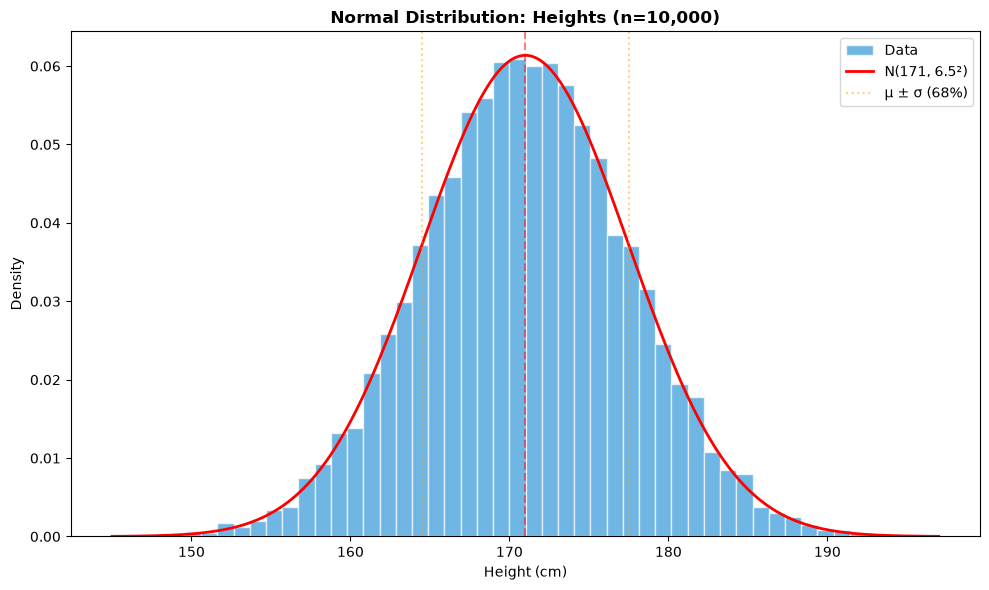

In [2]:
# Generate heights of 10,000 Indian males: N(171, 6.5²)
mu, sigma = 171, 6.5
heights = np.random.normal(mu, sigma, 10000)

print(f"Sample mean:  {np.mean(heights):.1f} cm (true μ = {mu})")
print(f"Sample std:   {np.std(heights):.1f} cm (true σ = {sigma})")
print()

# 68-95-99.7 Rule verification
for k, expected in [(1, 68), (2, 95), (3, 99.7)]:
    within = np.sum((heights >= mu - k*sigma) & (heights <= mu + k*sigma)) / len(heights) * 100
    print(f"Within {k}σ ({mu-k*sigma:.1f}-{mu+k*sigma:.1f} cm): {within:.1f}% (expected ~{expected}%)")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(heights, bins=50, density=True, alpha=0.7, color='#3498DB', edgecolor='white', label='Data')
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label=f'N({mu}, {sigma}²)')
ax.axvline(mu, color='red', ls='--', alpha=0.5)
ax.axvline(mu-sigma, color='orange', ls=':', alpha=0.5)
ax.axvline(mu+sigma, color='orange', ls=':', alpha=0.5, label='μ ± σ (68%)')
ax.set_xlabel('Height (cm)')
ax.set_ylabel('Density')
ax.set_title('Normal Distribution: Heights (n=10,000)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Z-Scores: How Unusual Is a Value?

$$z = \frac{x - \mu}{\sigma}$$

In [3]:
test_heights = [160, 171, 180, 190, 195]
print("Height  →  Z-score  →  Interpretation")
print("-" * 50)
for h in test_heights:
    z = (h - mu) / sigma
    p_extreme = 2 * (1 - stats.norm.cdf(abs(z)))
    label = 'TYPICAL' if abs(z) < 2 else 'UNUSUAL' if abs(z) < 3 else 'VERY RARE'
    print(f"{h:>5} cm  →  z = {z:>+5.2f}  →  {label} (P={p_extreme:.4f})")

print(f"\nP(height < 180) = {stats.norm.cdf(180, mu, sigma):.4f}")
print(f"P(height > 185) = {1 - stats.norm.cdf(185, mu, sigma):.4f}")

Height  →  Z-score  →  Interpretation
--------------------------------------------------
  160 cm  →  z = -1.69  →  TYPICAL (P=0.0906)
  171 cm  →  z = +0.00  →  TYPICAL (P=1.0000)
  180 cm  →  z = +1.38  →  TYPICAL (P=0.1662)
  190 cm  →  z = +2.92  →  UNUSUAL (P=0.0035)
  195 cm  →  z = +3.69  →  VERY RARE (P=0.0002)

P(height < 180) = 0.9169
P(height > 185) = 0.0156


In [4]:
stats.norm.cdf(x=180, loc=171, scale=6.5)

np.float64(0.916914947658562)

In [5]:
stats.norm.cdf((9/6.5))

np.float64(0.916914947658562)

In [6]:
stats.norm.cdf(x=189,loc=171,scale=6.5)-stats.norm.cdf(x=155,loc=171,scale=6.5)

np.float64(0.990273430732726)

In [7]:
stats.norm.cdf(x=177.5,loc=171,scale=6.5)-stats.norm.cdf(x=164.5,loc=171,scale=6.5)

np.float64(0.6826894921370859)

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 2: Binomial Distribution</h2>
</div>

The Binomial distribution models the number of **successes** in **n independent trials**, each with probability **p**.

Binomial(n=100, p=0.05)
Expected defectives: n×p = 5.0
Std dev: √(np(1-p)) = 2.18

P(exactly  0 defective) = 0.0059
P(exactly  3 defective) = 0.1396
P(exactly  5 defective) = 0.1800
P(exactly  8 defective) = 0.0649
P(exactly 10 defective) = 0.0167

P(≤ 3 defective)  = 0.2578
P(> 8 defective)   = 0.0631


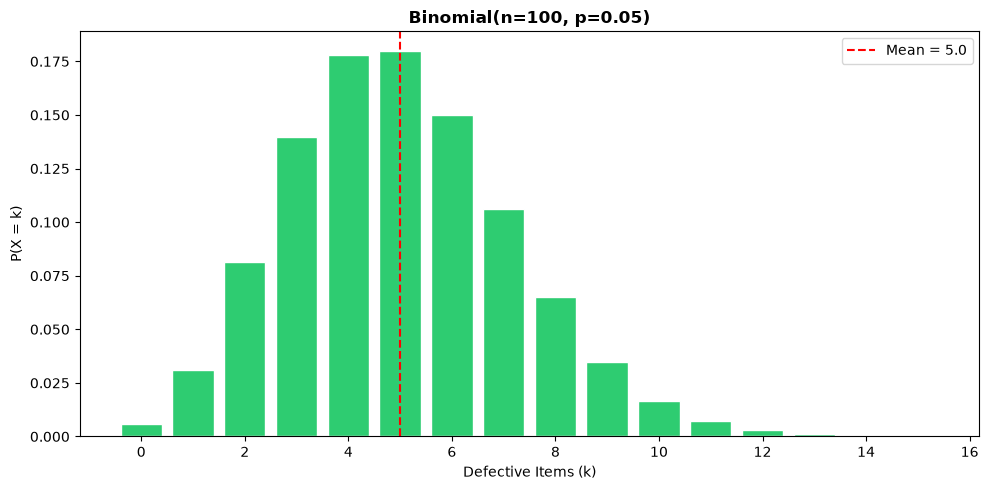

In [8]:
# Quality control: 100 items, 5% defect rate
n, p = 100, 0.05

print(f"Binomial(n={n}, p={p})")
print(f"Expected defectives: n×p = {n*p:.1f}")
print(f"Std dev: √(np(1-p)) = {np.sqrt(n*p*(1-p)):.2f}")
print()

for k in [0, 3, 5, 8, 10]:
    print(f"P(exactly {k:>2d} defective) = {stats.binom.pmf(k, n, p):.4f}")

print(f"\nP(≤ 3 defective)  = {stats.binom.cdf(3, n, p):.4f}")
print(f"P(> 8 defective)   = {1 - stats.binom.cdf(8, n, p):.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
k_vals = np.arange(0, 16)
ax.bar(k_vals, stats.binom.pmf(k_vals, n, p), color='#2ECC71', edgecolor='white')
ax.axvline(n*p, color='red', ls='--', label=f'Mean = {n*p}')
ax.set_xlabel('Defective Items (k)')
ax.set_ylabel('P(X = k)')
ax.set_title(f'Binomial(n={n}, p={p})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
n, p = 100, 0.05

In [17]:
stats.binom.pmf(0, n, p)

np.float64(0.005920529220334024)

In [18]:
stats.binom.pmf(1, n, p)

np.float64(0.031160680107021173)

In [19]:
stats.binom.pmf(2, n, p)

np.float64(0.08118177185776576)

In [20]:
stats.binom.pmf(3, n, p)

np.float64(0.13957567793089534)

In [ ]:
stats.binom.pmf(0, n, p)

In [21]:
stats.binom.pmf(0, n, p)+stats.binom.pmf(1, n, p)+stats.binom.pmf(2, n, p)+stats.binom.pmf(3, n, p)

np.float64(0.25783865911601633)

In [22]:
stats.binom.cdf(3, n, p)

np.float64(0.2578386591160152)

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 3: Poisson Distribution</h2>
</div>

The Poisson distribution models **events per interval**. Its unique property: **mean = variance = λ**.

Poisson(λ=50)
Mean = 50, Variance = 50 (mean = variance!)

P(≤ 40 visits)  = 0.0861
P(> 60 visits)   = 0.0722
P(> 80 visits)   = 0.000034


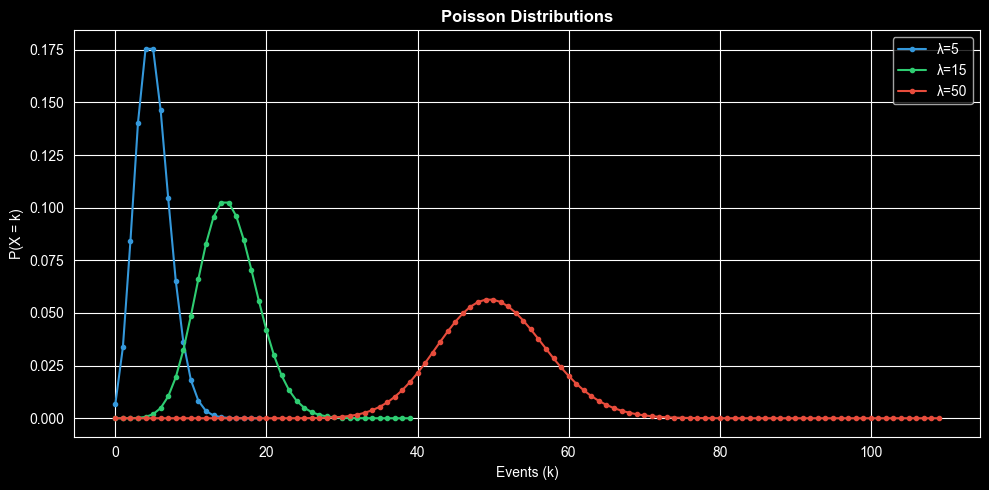

As λ increases, Poisson approaches Normal shape.


In [10]:
# Website traffic: average 50 visitors/hour
lam = 50

print(f"Poisson(λ={lam})")
print(f"Mean = {lam}, Variance = {lam} (mean = variance!)")
print()

print(f"P(≤ 40 visits)  = {stats.poisson.cdf(40, lam):.4f}")
print(f"P(> 60 visits)   = {1 - stats.poisson.cdf(60, lam):.4f}")
print(f"P(> 80 visits)   = {1 - stats.poisson.cdf(80, lam):.6f}")

# Compare different λ values
fig, ax = plt.subplots(figsize=(10, 5))
for l, c in [(5, '#3498DB'), (15, '#2ECC71'), (50, '#E74C3C')]:
    k = np.arange(0, l*2+10)
    ax.plot(k, stats.poisson.pmf(k, l), 'o-', color=c, ms=3, label=f'λ={l}')
ax.set_xlabel('Events (k)')
ax.set_ylabel('P(X = k)')
ax.set_title('Poisson Distributions', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print("As λ increases, Poisson approaches Normal shape.")

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 4: Exponential & Uniform</h2>
</div>

Exponential: 12 customers/hour → mean wait = 5 min
P(wait < 3 min) = 0.4512
P(wait > 10 min) = 0.1353

Uniform(0, 10)
P(X > 7) = 0.30
P(3 < X < 6) = 0.30


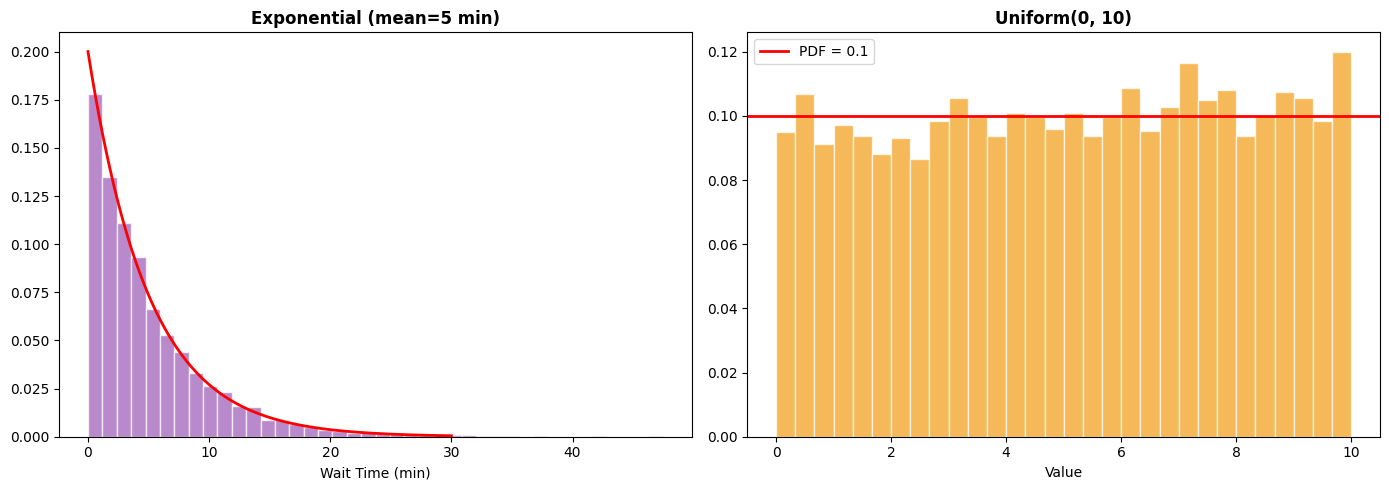

In [6]:
# Exponential: 12 customers/hour → mean wait = 5 min
rate = 12
scale_min = 60 / rate  # 5 minutes

print(f"Exponential: {rate} customers/hour → mean wait = {scale_min:.0f} min")
print(f"P(wait < 3 min) = {stats.expon.cdf(3, scale=scale_min):.4f}")
print(f"P(wait > 10 min) = {1 - stats.expon.cdf(10, scale=scale_min):.4f}")
print()

# Uniform: random number between 0 and 10
a, b = 0, 10
print(f"Uniform({a}, {b})")
print(f"P(X > 7) = {1 - stats.uniform.cdf(7, loc=a, scale=b-a):.2f}")
print(f"P(3 < X < 6) = {stats.uniform.cdf(6, loc=a, scale=b-a) - stats.uniform.cdf(3, loc=a, scale=b-a):.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wait_data = np.random.exponential(scale_min, 5000)
axes[0].hist(wait_data, bins=40, density=True, alpha=0.7, color='#9B59B6', edgecolor='white')
x_exp = np.linspace(0, 30, 200)
axes[0].plot(x_exp, stats.expon.pdf(x_exp, scale=scale_min), 'r-', lw=2)
axes[0].set_title(f'Exponential (mean={scale_min:.0f} min)', fontweight='bold')
axes[0].set_xlabel('Wait Time (min)')

unif_data = np.random.uniform(a, b, 5000)
axes[1].hist(unif_data, bins=30, density=True, alpha=0.7, color='#F39C12', edgecolor='white')
axes[1].axhline(1/(b-a), color='red', lw=2, label=f'PDF = {1/(b-a):.1f}')
axes[1].set_title(f'Uniform({a}, {b})', fontweight='bold')
axes[1].set_xlabel('Value')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 5: SciPy Distribution Fitting</h2>
</div>

Fit distributions to data using `stats.distribution.fit(data)` and overlay the fitted PDF.

Fitted: N(μ=71.67, σ=8.53)


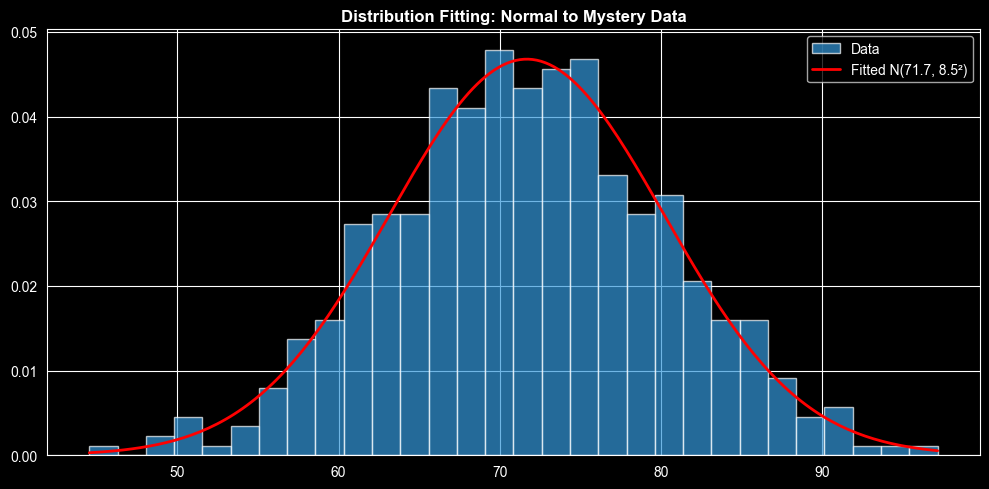

In [11]:
# Mystery data (Normal, but we "don't know")
np.random.seed(123)
mystery = np.random.normal(72, 8.5, 500)

# Fit Normal
mu_fit, sigma_fit = stats.norm.fit(mystery)
print(f"Fitted: N(μ={mu_fit:.2f}, σ={sigma_fit:.2f})")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mystery, bins=30, density=True, alpha=0.7, color='#3498DB', edgecolor='white', label='Data')
x = np.linspace(mystery.min(), mystery.max(), 200)
ax.plot(x, stats.norm.pdf(x, mu_fit, sigma_fit), 'r-', lw=2,
        label=f'Fitted N({mu_fit:.1f}, {sigma_fit:.1f}²)')
ax.set_title('Distribution Fitting: Normal to Mystery Data', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 6: Decision Flowchart</h2>
</div>

```
What are you modeling?
├── COUNTS (integers)?
│   ├── Fixed n trials? → BINOMIAL(n, p)
│   └── Events per interval? → POISSON(λ)
└── MEASUREMENTS (continuous)?
    ├── Bell-shaped? → NORMAL(μ, σ)
    ├── Time between events? → EXPONENTIAL(λ)
    └── All values equally likely? → UNIFORM(a, b)
```

<div style="background-color:#ED1C24; color:white; padding:15px 25px; border-radius:8px; margin:20px 0;">
<h2 style="color:white; margin:0;">Part 7: Mini-Project — Distribution Detective</h2>
</div>

MINI-PROJECT: Distribution Detective


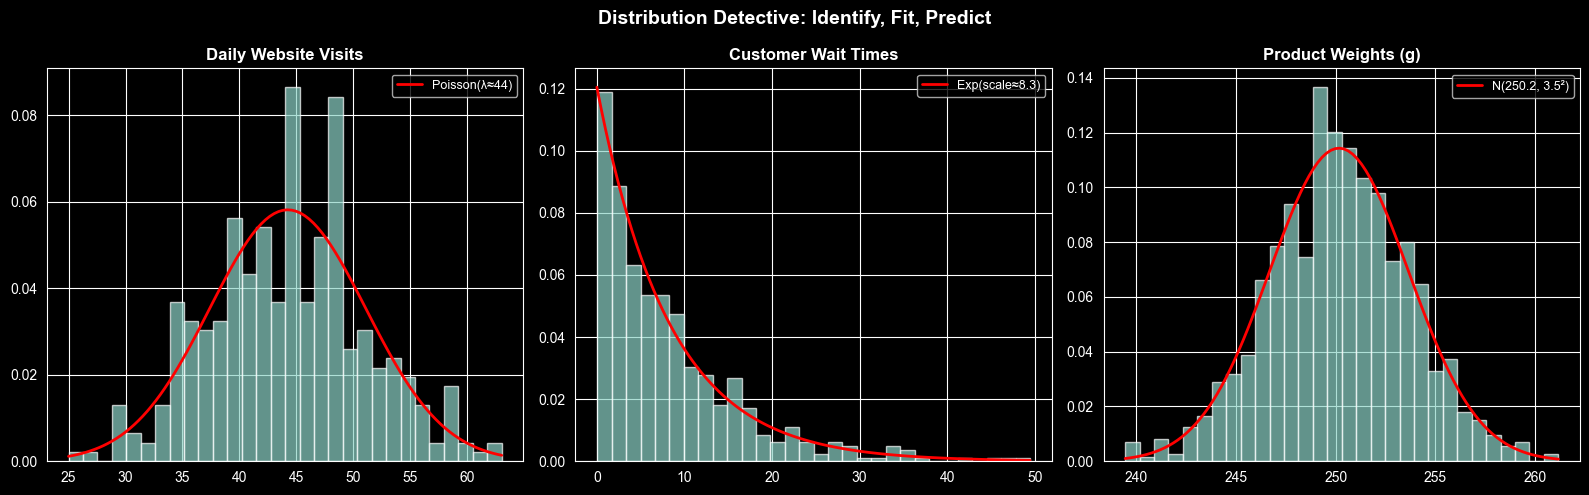


=== PREDICTIONS ===
Visits: P(> 60 tomorrow) = 0.0097
Wait: P(> 15 min) = 0.1641
Weight: P(< 245g) = 0.0694 ← quality reject threshold


In [12]:
print("=" * 60)
print("MINI-PROJECT: Distribution Detective")
print("=" * 60)

np.random.seed(42)
# Mystery 1: Poisson (website visits/day)
d1 = np.random.poisson(lam=45, size=365)
# Mystery 2: Exponential (wait times in minutes)
d2 = np.random.exponential(scale=8.0, size=500)
# Mystery 3: Normal (product weights)
d3 = np.random.normal(loc=250, scale=3.5, size=1000)

datasets = [("Daily Website Visits", d1), ("Customer Wait Times", d2), ("Product Weights (g)", d3)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, data) in zip(axes, datasets):
    ax.hist(data, bins=30, density=True, alpha=0.7, edgecolor='white')

    # Fit and overlay
    if 'Visit' in name:  # Poisson → Normal approx for overlay
        m, s = np.mean(data), np.std(data)
        x = np.linspace(data.min(), data.max(), 100)
        ax.plot(x, stats.norm.pdf(x, m, s), 'r-', lw=2, label=f'Poisson(λ≈{m:.0f})')
    elif 'Wait' in name:  # Exponential
        _, sc = stats.expon.fit(data, floc=0)
        x = np.linspace(0, data.max(), 100)
        ax.plot(x, stats.expon.pdf(x, scale=sc), 'r-', lw=2, label=f'Exp(scale≈{sc:.1f})')
    else:  # Normal
        m, s = stats.norm.fit(data)
        x = np.linspace(data.min(), data.max(), 100)
        ax.plot(x, stats.norm.pdf(x, m, s), 'r-', lw=2, label=f'N({m:.1f}, {s:.1f}²)')

    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Distribution Detective: Identify, Fit, Predict', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Predictions
print("\n=== PREDICTIONS ===")
print(f"Visits: P(> 60 tomorrow) = {1 - stats.poisson.cdf(60, np.mean(d1)):.4f}")
print(f"Wait: P(> 15 min) = {1 - stats.expon.cdf(15, scale=np.mean(d2)):.4f}")
m_w, s_w = stats.norm.fit(d3)
print(f"Weight: P(< 245g) = {stats.norm.cdf(245, m_w, s_w):.4f} ← quality reject threshold")

<div style="background: #EAFAF1; color: black; border-left: 5px solid #2ECC71; padding: 15px; margin: 15px 0;">
<strong>✅ Key Takeaways:</strong>
<ol>
<li><strong>Normal:</strong> Bell curve, μ±σ bands, z-scores. The most common distribution.</li>
<li><strong>68-95-99.7:</strong> 1σ=68%, 2σ=95%, 3σ=99.7%. Beyond 3σ = outlier.</li>
<li><strong>Binomial:</strong> n trials, p probability, count successes.</li>
<li><strong>Poisson:</strong> Events per interval. Mean = Variance = λ.</li>
<li><strong>Exponential:</strong> Time between events. Mean = 1/λ. Memoryless.</li>
<li><strong>Uniform:</strong> Equal probability in [a, b].</li>
<li><strong>SciPy .fit():</strong> Estimates parameters from data.</li>
<li><strong>Flowchart:</strong> Discrete → Binomial/Poisson. Continuous → Normal/Exponential/Uniform.</li>
</ol>
</div>

## What's Next

**Session 7.2: Statistical Inference & Hypothesis Testing** — CLT (why Normal is everywhere), confidence intervals, p-values, hypothesis testing.

---
<div style="text-align:center; color:#666; padding:20px;"><em>Vishlesan i-Hub IIT Patna × Masai School</em></div>